In [1]:
from google.colab import auth
auth.authenticate_user()

import pandas as pd
from google.cloud import bigquery

project_id = "bis638proj"
dataset_id = "Final_proj"

client = bigquery.Client(project=project_id)


In [2]:
query = """
SELECT *
FROM `bis638proj.Final_proj.cleaned_data`
"""
df = client.query(query).to_dataframe()
df.shape

(5297, 148)

In [3]:
counts = df['hospital_expire_flag'].value_counts()

# 2. Get percentages (normalized)
percentages = df['hospital_expire_flag'].value_counts(normalize=True) * 100

# Print the results
print("Raw Counts:")
print(counts)
print("\nPercentages:")
print(percentages)

Raw Counts:
hospital_expire_flag
0    4036
1    1261
Name: count, dtype: Int64

Percentages:
hospital_expire_flag
0    76.194072
1    23.805928
Name: proportion, dtype: Float64


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report

In [5]:
target = "hospital_expire_flag"

# Columns we don't want to use as features
id_cols = [
    "subject_id", "hadm_id", "stay_id",
    "Group_Name", "Term", "DOID", "ICD10Code"
]

time_cols = [
    "dod", "admittime", "dischtime",
    "icu_intime", "icu_outtime",
    "admittime_1", "dischtime_1", "deathtime", "dod_1"
]

leak_cols = ["los_hospital", "los_icu"]

drop_cols = id_cols + time_cols + leak_cols + [target] + ["race"]


X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target]

# Make sure bools are numeric (0/1)
bool_cols = X.select_dtypes("bool").columns
X[bool_cols] = X[bool_cols].astype(int)

# Identify numeric and categorical feature columns
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(cat_cols))

Numeric cols: 125
Categorical cols: 6


In [6]:
X.isna().sum().sum()


np.int64(0)

In [8]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

subjects = df["subject_id"].unique()
rng = np.random.default_rng(638)
# assign the subject ids to random order and pick 80%
rng.shuffle(subjects)
n_train_subj = int(0.8 * len(subjects))
# split the train and test ids
train_subj = subjects[:n_train_subj]
test_subj = subjects[n_train_subj:]

# extract the corresponding patients' records
train_mask = df["subject_id"].isin(train_subj).values
test_mask = ~train_mask
# split the train and test data
X_train = X.loc[train_mask, :]
y_train = y.loc[train_mask]
X_test = X.loc[test_mask, :]
y_test = y.loc[test_mask]

# extract the train and test ids in order
codes_train, uniq_train = pd.factorize(df.loc[train_mask, "subject_id"])
codes_test, uniq_test = pd.factorize(df.loc[test_mask, "subject_id"])
# turn them to id index
ids_train = codes_train.astype(int)
ids_test  = codes_test.astype(int)

/tmp/ipython-input-419942663.py:19: UserWarning: you are shuffling a 'IntegerArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(subjects)


In [9]:
logit_cv = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    refit=True
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logit_cv)
])

clf.fit(X_train, y_train)

y_proba_logit = clf.predict_proba(X_test)[:, 1]   # P(death)
y_pred_logit  = clf.predict(X_test)               # 0/1 prediction

print("Test AUC:", roc_auc_score(y_test, y_proba_logit))
print(classification_report(y_test, y_pred_logit))


Test AUC: 0.8071147773409808
              precision    recall  f1-score   support

         0.0       0.83      0.96      0.89       885
         1.0       0.70      0.33      0.45       263

    accuracy                           0.82      1148
   macro avg       0.77      0.65      0.67      1148
weighted avg       0.80      0.82      0.79      1148



In [10]:
preprocess = clf.named_steps["preprocess"]
logit_cv   = clf.named_steps["model"]

feature_names = preprocess.get_feature_names_out()

coefs = logit_cv.coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
})
coef_df["abs_coef"] = coef_df["coef"].abs()

nonzero_coef_df = coef_df[coef_df["coef"] != 0].copy()

top_k = 20
top_features = nonzero_coef_df.sort_values("abs_coef", ascending=False).head(top_k)

#print(top_features)

In [11]:
def adjust_feature_name(raw: str) -> str:
    """
    Turn names like 'num__anchor_age' or 'cat__gender_F'
    into 'anchor_age' or 'gender = F'.
    """
    if "__" in raw:
        prefix, rest = raw.split("__", 1)
    else:
        rest = raw

    if "_" in rest:
        base, level = rest.split("_", 1)
        if prefix == "cat":
            return f"{base} = {level}"
        else:
            return rest
    else:
        return rest

top_k = 20
top_features = (
    nonzero_coef_df
    .sort_values("abs_coef", ascending=False)
    .head(top_k)
    .copy()
)

top_features["feature_name"] = top_features["feature"].apply(adjust_feature_name)
top_features


,feature,coef,abs_coef,feature_name
0,num__admission_age,0.259894,0.259894,admission_age
119,num__urineoutput,-0.240641,0.240641,urineoutput
48,num__fibrinogen_max,-0.236287,0.236287,fibrinogen_max
63,num__ck_cpk_min,-0.184970,0.184970,ck_cpk_min
67,num__ld_ldh_min,0.161965,0.161965,ld_ldh_min
11,num__platelets_min,-0.157468,0.157468,platelets_min
13,num__wbc_min,0.144710,0.144710,wbc_min
151,cat__marital_status_SINGLE,-0.142390,0.142390,marital = status_SINGLE
86,num__temperature_mean,-0.141382,0.141382,temperature_mean
21,num__bun_min,0.131782,0.131782,bun_min


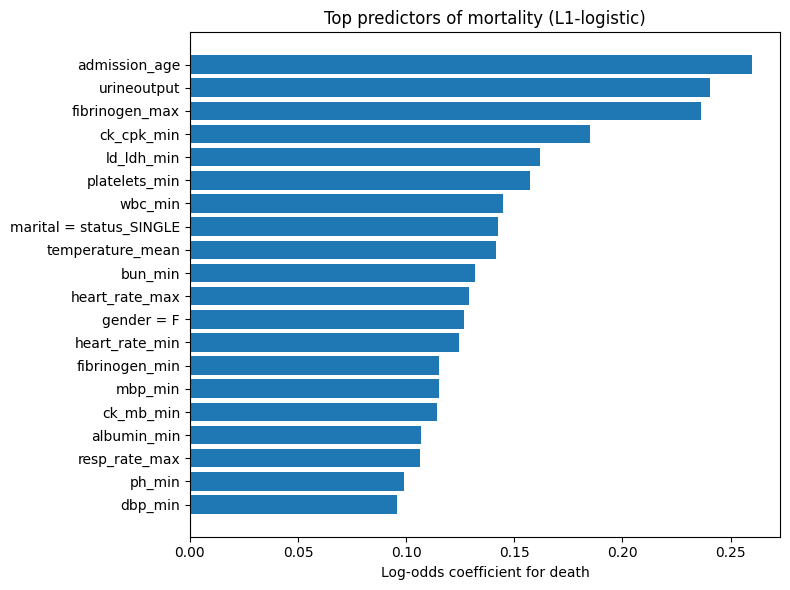

In [12]:
import matplotlib.pyplot as plt

plot_df = top_features.sort_values("abs_coef")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature_name"], plot_df["abs_coef"])
plt.axvline(0, linestyle="--")
plt.xlabel("Log-odds coefficient for death")
plt.title("Top predictors of mortality (L1-logistic)")
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report

from xgboost import XGBClassifier

In [14]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

clf_xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb_model)
])

clf_xgb.fit(X_train, y_train)

y_proba_xgb = clf_xgb.predict_proba(X_test)[:, 1]  # predicted P(death)
y_pred_xgb  = clf_xgb.predict(X_test)              # 0/1 prediction

print("XGBoost Test AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Test AUC: 0.9225881291486756
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92       885
         1.0       0.88      0.54      0.67       263

    accuracy                           0.88      1148
   macro avg       0.88      0.76      0.80      1148
weighted avg       0.88      0.88      0.87      1148



In [15]:
preprocess = clf_xgb.named_steps["preprocess"]
xgb_model  = clf_xgb.named_steps["model"]

feature_names = preprocess.get_feature_names_out()

importances = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi_df = fi_df.sort_values("importance", ascending=False)

top_k = 20
top_importances = fi_df.head(top_k)
#print(top_importances)

In [16]:
fi_df["feature_name"] = fi_df["feature"].apply(adjust_feature_name)
top_importances = fi_df.head(top_k)
print(top_importances[["feature_name", "importance"]])


                feature_name  importance
94               lactate_max    0.031232
61       bilirubin_total_min    0.017987
107           baseexcess_min    0.017390
93               lactate_min    0.015663
111        temperature_min_1    0.015276
62       bilirubin_total_max    0.014533
49                   inr_min    0.012488
0              admission_age    0.012416
119              urineoutput    0.012286
151  marital = status_SINGLE    0.012107
80                  mbp_mean    0.011916
30               glucose_max    0.011895
16               albumin_max    0.011474
71           heart_rate_mean    0.011400
15               albumin_min    0.011335
86          temperature_mean    0.010610
89                 spo2_mean    0.010276
59                   ast_min    0.009765
72                   sbp_min    0.009692
5                 anchor_age    0.009532


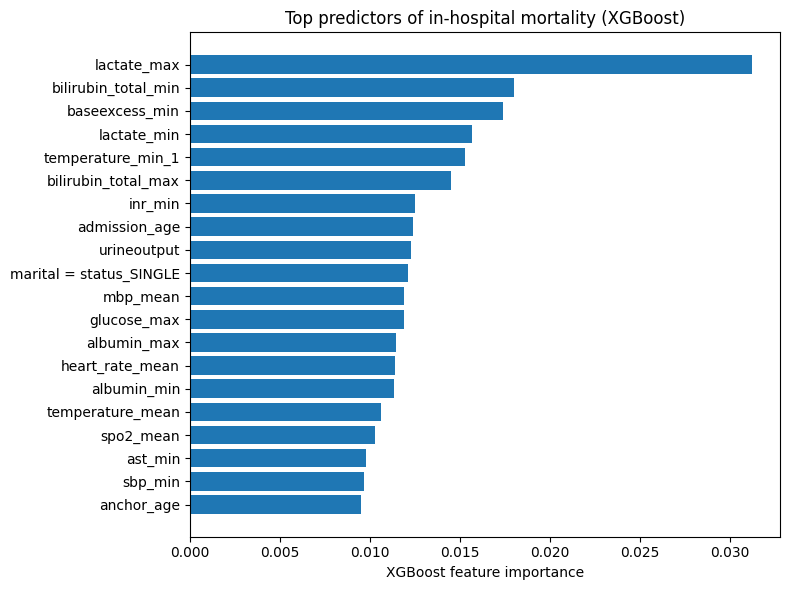

In [17]:
import matplotlib.pyplot as plt

plot_df = top_importances.sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature_name"], plot_df["importance"])
plt.xlabel("XGBoost feature importance")
plt.title("Top predictors of in-hospital mortality (XGBoost)")
plt.tight_layout()
plt.show()


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

clf_rf.fit(X_train, y_train)

y_proba_rf = clf_rf.predict_proba(X_test)[:, 1]   # P(death)
y_pred_rf  = clf_rf.predict(X_test)               # 0/1 prediction

print("Random Forest Test AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Test AUC: 0.9853665871839488
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96       885
         1.0       0.97      0.78      0.86       263

    accuracy                           0.94      1148
   macro avg       0.95      0.89      0.91      1148
weighted avg       0.95      0.94      0.94      1148



In [19]:
pre = clf_rf.named_steps["preprocess"]
rf_model = clf_rf.named_steps["model"]

feat_names = pre.get_feature_names_out()
importances = rf_model.feature_importances_

fi_rf = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

#fi_rf.head(20)

In [20]:
fi_rf["feature_name"] = fi_rf["feature"].apply(adjust_feature_name)
top_importances_rf = fi_rf.head(top_k)
top_importances_rf[["feature_name","importance"]]

,feature_name,importance
0,admission_age,0.019530
119,urineoutput,0.019289
5,anchor_age,0.016326
94,lactate_max,0.015904
21,bun_min,0.014469
93,lactate_min,0.014041
22,bun_max,0.013764
107,baseexcess_min,0.013116
11,platelets_min,0.013089
86,temperature_mean,0.013082


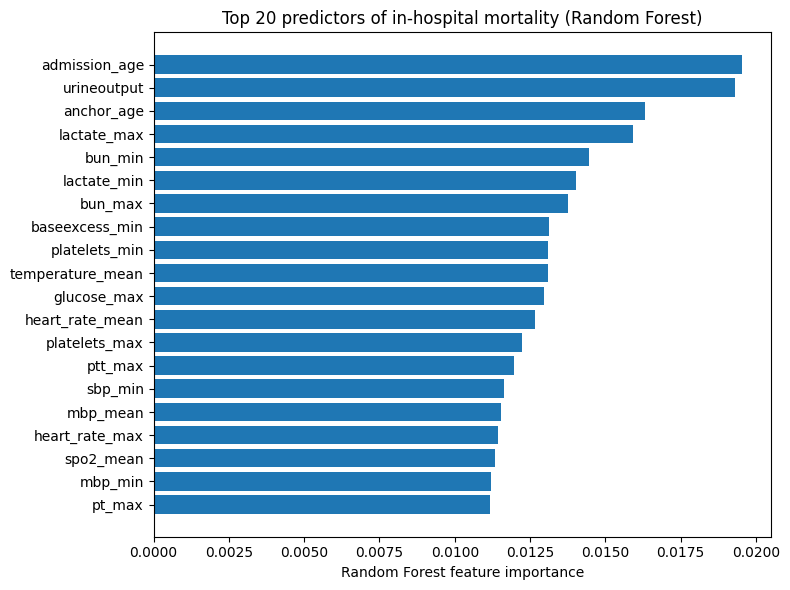

In [21]:
plot_df = top_importances_rf.sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature_name"], plot_df["importance"])
plt.xlabel("Random Forest feature importance")
plt.title("Top 20 predictors of in-hospital mortality (Random Forest)")
plt.tight_layout()
plt.savefig("rf_predictors.png", dpi=300, bbox_inches="tight")
plt.show()

1. Model comparison

In [22]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score
)
import pandas as pd

# 1) Logistic
y_proba_logit = clf.predict_proba(X_test)[:, 1]
y_pred_logit  = clf.predict(X_test)

# 2) Random Forest
y_proba_rf = clf_rf.predict_proba(X_test)[:, 1]
y_pred_rf  = clf_rf.predict(X_test)

# 3) XGBoost
y_proba_xgb = clf_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = clf_xgb.predict(X_test)

results = []

def add_row(name, y_true, y_proba, y_pred):
    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall_death": recall_score(y_true, y_pred, pos_label=1),
        "Precision_death": precision_score(y_true, y_pred, pos_label=1),
    })

add_row("Logistic (L1)", y_test, y_proba_logit, y_pred_logit)
add_row("XGBoost",       y_test, y_proba_xgb,  y_pred_xgb)
add_row("Random Forest", y_test, y_proba_rf,    y_pred_rf)

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.round(3)
print(metrics_df)

           Model    AUC  Accuracy  Recall_death  Precision_death
0  Logistic (L1)  0.807     0.815         0.335            0.704
1        XGBoost  0.923     0.877         0.540            0.877
2  Random Forest  0.985     0.944         0.779            0.972


2. ROC & Precision–Recall curves on one plot

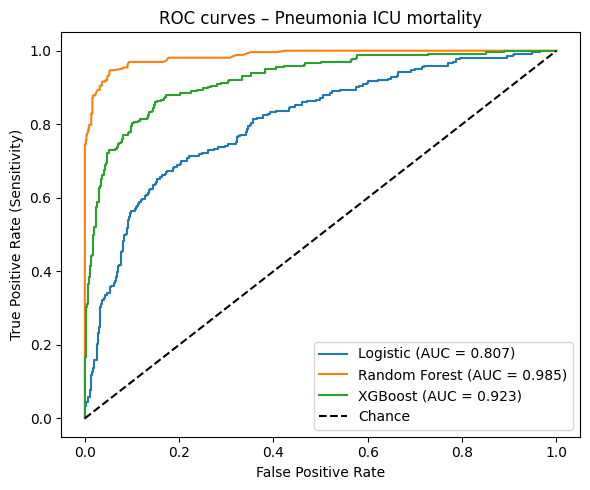

In [23]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

# predicted probabilities (P(death = 1))
y_proba_logit = clf.predict_proba(X_test)[:, 1]
y_proba_rf    = clf_rf.predict_proba(X_test)[:, 1]
y_proba_xgb   = clf_xgb.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6, 5))

# Logistic
fpr_l, tpr_l, _ = roc_curve(y_test, y_proba_logit)
auc_l = roc_auc_score(y_test, y_proba_logit)
plt.plot(fpr_l, tpr_l, label=f"Logistic (AUC = {auc_l:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# XGBoost
fpr_x, tpr_x, _ = roc_curve(y_test, y_proba_xgb)
auc_x = roc_auc_score(y_test, y_proba_xgb)
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC = {auc_x:.3f})")

# chance line
plt.plot([0, 1], [0, 1], "k--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC curves – Pneumonia ICU mortality")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


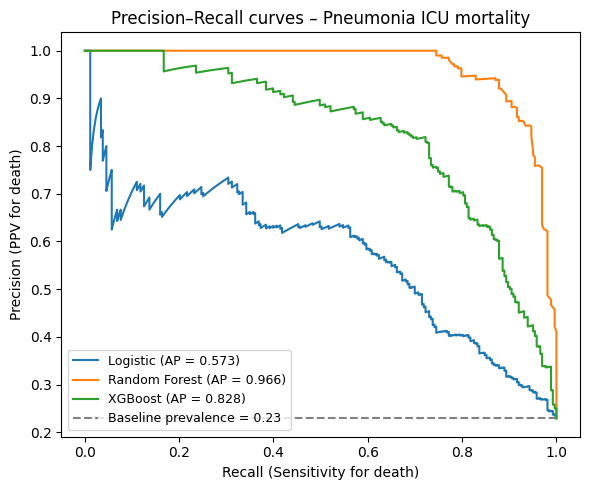

In [24]:
plt.figure(figsize=(6, 5))

# Logistic
prec_l, rec_l, _ = precision_recall_curve(y_test, y_proba_logit)
ap_l = average_precision_score(y_test, y_proba_logit)
plt.plot(rec_l, prec_l, label=f"Logistic (AP = {ap_l:.3f})")

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {ap_rf:.3f})")

# XGBoost
prec_x, rec_x, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_x = average_precision_score(y_test, y_proba_xgb)
plt.plot(rec_x, prec_x, label=f"XGBoost (AP = {ap_x:.3f})")

# baseline = prevalence of death
base = y_test.mean()
plt.hlines(base, 0, 1, colors="gray", linestyles="dashed",
           label=f"Baseline prevalence = {base:.2f}")

plt.xlabel("Recall (Sensitivity for death)")
plt.ylabel("Precision (PPV for death)")
plt.title("Precision–Recall curves – Pneumonia ICU mortality")
plt.legend(
    loc="lower left",
    frameon=True,
    fontsize=9
)
plt.tight_layout()
plt.tight_layout()
plt.show()


3. Threshold tuning: show how we trade off missing deaths vs false alarms

In [25]:
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix
)

thresholds = [0.2, 0.4, 0.5, 0.6, 0.8]

rows = []
for thr in thresholds:
    y_pred_thr = (y_proba_rf >= thr).astype(int)  # 1 = predict death

    prec = precision_score(y_test, y_pred_thr, pos_label=1)
    rec  = recall_score(y_test, y_pred_thr,   pos_label=1)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    specificity = tn / (tn + fp)   # true negative rate

    rows.append({
        "Threshold": thr,
        "Recall_death": rec,
        "Precision_death": prec,
        "Specificity_survival": specificity,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    })

thresh_df = pd.DataFrame(rows).round(3)
print(thresh_df)


   Threshold  Recall_death  Precision_death  Specificity_survival   TP   FP  \
0        0.2         0.970            0.718                 0.887  255  100   
1        0.4         0.848            0.941                 0.984  223   14   
2        0.5         0.779            0.972                 0.993  205    6   
3        0.6         0.757            0.990                 0.998  199    2   
4        0.8         0.247            1.000                 1.000   65    0   

    FN   TN  
0    8  785  
1   40  871  
2   58  879  
3   64  883  
4  198  885  


4. Compare feature importance across models

In [26]:
pre = clf.named_steps["preprocess"]

num_feature_names = np.array(numeric_cols)

ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_feature_names, cat_feature_names])


In [27]:
def aggregate_importance(feature_names, importances):
    """
    feature_names: array of transformed feature names
    importances:   array of importance values (same length)

    Returns a DataFrame with importance summed per original feature.
    """
    base_names = []
    for name in feature_names:
        if name in numeric_cols:
            base_names.append(name)
        else:
            # one-hot names look like "race_Black", "gender_F"
            base_names.append(name.split("_", 1)[0])

    df_imp = pd.DataFrame({
        "feature": base_names,
        "importance": importances
    })

    agg = (
        df_imp.groupby("feature", as_index=False)["importance"]
              .sum()
              .sort_values("importance", ascending=False)
    )
    return agg


In [28]:
# Logistic
logit = clf.named_steps["model"]
coef = logit.coef_.ravel()            # shape (n_features,)
imp_logit = aggregate_importance(feature_names, np.abs(coef))


In [29]:
# XGBoost
xgb = clf_xgb.named_steps["model"]
imp_xgb = aggregate_importance(feature_names, xgb.feature_importances_)


In [30]:
# Random forest
rf = clf_rf.named_steps["model"]
imp_rf = aggregate_importance(feature_names, rf.feature_importances_)


In [31]:
TOP_K = 20

top_feat = (
    set(imp_logit.head(TOP_K)["feature"]) |
    set(imp_rf.head(TOP_K)["feature"])     |
    set(imp_xgb.head(TOP_K)["feature"])
)

combined = pd.DataFrame(index=sorted(top_feat))
combined["Logistic_L1"] = combined.index.map(
    dict(zip(imp_logit["feature"], imp_logit["importance"]))
)
combined["RandomForest"] = combined.index.map(
    dict(zip(imp_rf["feature"], imp_rf["importance"]))
)
combined["XGBoost"] = combined.index.map(
    dict(zip(imp_xgb["feature"], imp_xgb["importance"]))
)

combined = combined.fillna(0)

# normalize each model’s column so max = 1 (easier to compare)
combined_norm = combined.divide(combined.max())

print(combined_norm.round(3))


                     Logistic_L1  RandomForest  XGBoost
admission                  0.000         0.459    1.000
admission_age              1.000         1.000    0.318
albumin_max                0.233         0.469    0.294
albumin_min                0.411         0.483    0.290
anchor_age                 0.000         0.836    0.244
ast_min                    0.000         0.453    0.250
baseexcess_min             0.000         0.672    0.445
bilirubin_total_max        0.277         0.484    0.372
bilirubin_total_min        0.272         0.388    0.461
bun_max                    0.000         0.705    0.218
bun_min                    0.507         0.741    0.240
ck_cpk_min                 0.712         0.245    0.180
ck_mb_min                  0.440         0.170    0.000
dbp_min                    0.369         0.548    0.168
fibrinogen_max             0.909         0.238    0.180
fibrinogen_min             0.444         0.183    0.186
gender                     0.488         0.117  

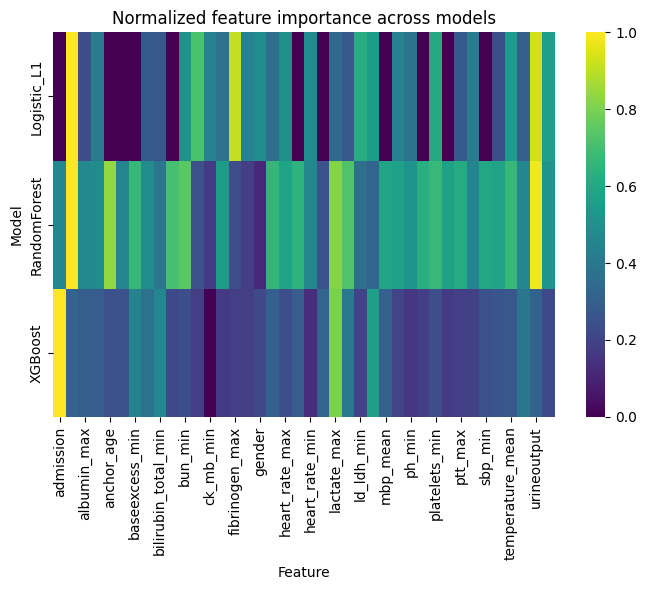

In [32]:
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.heatmap(combined_norm.T, annot=False, cmap="viridis")
plt.xlabel("Feature")
plt.ylabel("Model")
plt.title("Normalized feature importance across models")
plt.tight_layout()
plt.show()


In [33]:
TOP_K = 20

# 1) features that ever appear in top-K of any model
top_features = (
    set(imp_logit.nlargest(TOP_K, "importance")["feature"]) |
    set(imp_rf.nlargest(TOP_K, "importance")["feature"])     |
    set(imp_xgb.nlargest(TOP_K, "importance")["feature"])
)
top_features = sorted(top_features)

def selected_from_imp(imp_df, thresh_ratio=0.15):
    """Return a set of features whose importance is ≥ thresh_ratio * max."""
    max_imp = imp_df["importance"].max()
    cutoff = thresh_ratio * max_imp
    return set(imp_df.loc[imp_df["importance"] >= cutoff, "feature"])

sel_L   = selected_from_imp(imp_logit, thresh_ratio=0.15)
sel_RF  = selected_from_imp(imp_rf,    thresh_ratio=0.15)
sel_XGB = selected_from_imp(imp_xgb,   thresh_ratio=0.15)

presence = pd.DataFrame({
    "Feature": top_features,
    "L_logit": [f in sel_L   for f in top_features],
    "RF":      [f in sel_RF  for f in top_features],
    "XGB":     [f in sel_XGB for f in top_features],
})

print(presence.head())


         Feature  L_logit    RF   XGB
0      admission    False  True  True
1  admission_age     True  True  True
2    albumin_max     True  True  True
3    albumin_min     True  True  True
4     anchor_age    False  True  True


In [34]:
def dot(b, ch_filled, ch_empty="○"):
    return ch_filled if b else ch_empty

presence["Markers"] = [
    f"{dot(L,  '🔵')} {dot(RF, '🟠')} {dot(XGB,'🟢')}"
    for L, RF, XGB in zip(presence["L_logit"], presence["RF"], presence["XGB"])
]

presence_display = presence[["Feature", "Markers"]]
#print(presence_display.to_string(index=False))


In [35]:
query = """
SELECT *
FROM `bis638proj.Final_proj.pip_table`
"""
pip = client.query(query).to_dataframe()
pip

,index,feature,PIP
0,2,first_hosp_stay,1.000000
1,119,urineoutput,1.000000
2,70,heart_rate_max,0.995833
3,112,temperature_max_1,0.867583
4,111,temperature_min_1,0.866875
5,86,temperature_mean,0.725417
6,62,bilirubin_total_max,0.691125
7,16,albumin_max,0.676708
8,65,ck_mb_min,0.670250
9,135,admission_location_INTERNAL TRANSFER TO OR FRO...,0.592500


/tmp/ipython-input-2070366731.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


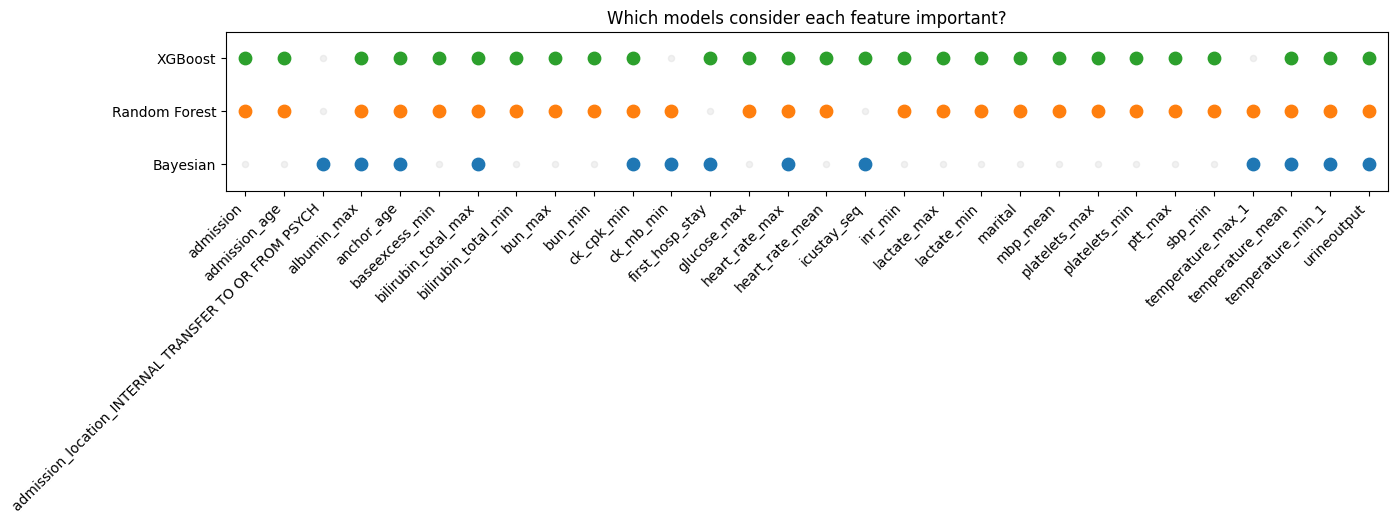

In [36]:
def collapse_race(name: str) -> str:
    """Map all race_* features to 'race'."""
    return "race" if name.startswith("race_") else name
# Collapse + aggregate PIP
pip_collapsed = pip.copy()
pip_collapsed["feature"] = pip_collapsed["feature"].apply(collapse_race)

pip_agg = (pip_collapsed
           .groupby("feature", as_index=False)["PIP"]
           .mean()
           .sort_values("PIP", ascending=False))

# Use the aggregated features here (you can add a threshold if you want)
sel_Bayes = set(pip_agg["feature"])
def collapse_and_agg_imp(imp_df):
    df = imp_df.copy()
    df["feature"] = df["feature"].apply(collapse_race)
    # aggregate importance for features that became duplicates (e.g. race)
    df = df.groupby("feature", as_index=False)["importance"].mean()
    return df

imp_rf_c  = collapse_and_agg_imp(imp_rf)
imp_xgb_c = collapse_and_agg_imp(imp_xgb)
TOP_K = 15

def selected_from_imp(imp_df, thresh_ratio=0.15):
    max_imp = imp_df["importance"].max()
    cutoff = thresh_ratio * max_imp
    return set(imp_df.loc[imp_df["importance"] >= cutoff, "feature"])

sel_RF  = selected_from_imp(imp_rf_c,  thresh_ratio=0.15)
sel_XGB = selected_from_imp(imp_xgb_c, thresh_ratio=0.15)

top_features = (
    set(imp_rf_c.nlargest(TOP_K, "importance")["feature"])
    | set(imp_xgb_c.nlargest(TOP_K, "importance")["feature"])
    | sel_Bayes
)
top_features = sorted(top_features)

presence = pd.DataFrame({"Feature": top_features})
presence["Bayes"] = presence["Feature"].isin(sel_Bayes)
presence["RF"]    = presence["Feature"].isin(sel_RF)
presence["XGB"]   = presence["Feature"].isin(sel_XGB)

def dot(b, ch_filled, ch_empty="○"):
    return ch_filled if b else ch_empty

presence["Markers"] = [
    f"{dot(b, '🔵')} {dot(r, '🟠')} {dot(x, '🟢')}"
    for b, r, x in zip(presence["Bayes"], presence["RF"], presence["XGB"])
]

presence_display = presence[["Feature", "Markers"]]

import matplotlib.pyplot as plt

models     = ["Bayesian", "Random Forest", "XGBoost"]
model_keys = ["Bayes", "RF", "XGB"]
colors     = {"Bayes": "tab:blue", "RF": "tab:orange", "XGB": "tab:green"}

fig, ax = plt.subplots(figsize=(0.5 * len(top_features), 3))

for i, feat in enumerate(top_features):
    row = presence.iloc[i]
    for j, key in enumerate(model_keys):
        selected = row[key]
        if selected:
            ax.scatter(i, j, s=80, color=colors[key])
        else:
            ax.scatter(i, j, s=20, color="lightgray", alpha=0.3)

# Axes labels & ticks
ax.set_xticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha="right")
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)

ax.set_xlim(-0.5, len(top_features) - 0.5)
ax.set_ylim(-0.5, len(models) - 0.5)

ax.set_title("Which models consider each feature important?")

plt.tight_layout()
fig.subplots_adjust(bottom=0.35)
fig.savefig("feature_overlap.png", dpi=300, bbox_inches="tight")
plt.show()


5. Subgroup performance

In [37]:
age_test    = df.loc[test_mask, "admission_age"]
gender_test = df.loc[test_mask, "gender"]

# Age subgroups
young_mask = age_test < 65
old_mask   = age_test >= 65

# Gender subgroups
male_mask   = gender_test == "M"
female_mask = gender_test == "F"

In [38]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

def subgroup_metrics(mask, name):
    # 1. Filter to the subgroup
    y_true = y_test[mask]
    y_prob = y_proba_rf[mask]
    y_hat  = y_pred_rf[mask]

    # 2. AUC (needs probabilities)
    auc = roc_auc_score(y_true, y_prob) if y_true.nunique() == 2 else float("nan")

    # 3. Precision & recall for the death class (1)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_hat, labels=[1], average=None
    )
    prec_death = prec[0]
    rec_death  = rec[0]

    death_rate = y_true.mean()

    print(f"\n=== {name} ===")
    print(f"n = {len(y_true)}")
    print(f"Death rate:        {death_rate:.3f}")
    print(f"AUC: {auc:.3f}")
    print(f"Recall (death):    {rec_death:.3f}")
    print(f"Precision (death): {prec_death:.3f}")

    return {
        "Subgroup": name,
        "n": len(y_true),
        "Death_rate": death_rate,
        "AUC": auc,
        "Recall_death": rec_death,
        "Precision_death": prec_death,
    }

In [39]:
clf_rf.fit(X_train, y_train)

# store probs/preds as Series aligned with y_test index
y_proba_test = pd.Series(
    clf_rf.predict_proba(X_test)[:, 1],
    index=y_test.index
)
y_pred_test = pd.Series(
    clf_rf.predict(X_test),
    index=y_test.index
)

print("Overall RF AUC:", roc_auc_score(y_test, y_proba_test))


Overall RF AUC: 0.9853665871839488


In [40]:
import pandas as pd
metrics = [
    subgroup_metrics(young_mask, "Age < 65"),
    subgroup_metrics(old_mask,   "Age ≥ 65"),
    subgroup_metrics(male_mask,  "Male"),
    subgroup_metrics(female_mask,"Female"),
]
pd.DataFrame(metrics)



=== Age < 65 ===
n = 417
Death rate:        0.194
AUC: 0.995
Recall (death):    0.778
Precision (death): 0.984

=== Age ≥ 65 ===
n = 731
Death rate:        0.249
AUC: 0.979
Recall (death):    0.780
Precision (death): 0.966

=== Male ===
n = 698
Death rate:        0.238
AUC: 0.990
Recall (death):    0.819
Precision (death): 0.971

=== Female ===
n = 450
Death rate:        0.216
AUC: 0.977
Recall (death):    0.711
Precision (death): 0.972


,Subgroup,n,Death_rate,AUC,Recall_death,Precision_death
0,Age < 65,417,0.194245,0.995076,0.777778,0.984375
1,Age ≥ 65,731,0.248974,0.979238,0.780220,0.965986
2,Male,698,0.237822,0.990069,0.819277,0.971429
3,Female,450,0.215556,0.977103,0.711340,0.971831


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rf_calib = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba_rf
})

# Define 3 intuitive risk groups by predicted probability
bins = [0.0, 0.1, 0.3, 1.0]
labels = ["Low (0–10%)", "Medium (10–30%)", "High (>30%)"]

rf_calib["risk_group"] = pd.cut(
    rf_calib["y_proba"], bins=bins, labels=labels, include_lowest=True
)

calib3 = (
    rf_calib
    .groupby("risk_group")
    .agg(
        n=("y_true", "size"),
        pred_mean=("y_proba", "mean"),
        obs_rate=("y_true", "mean")
    )
    .reset_index()
)

print(calib3)


        risk_group    n  pred_mean  obs_rate
0      Low (0–10%)  552   0.048068  0.001812
1  Medium (10–30%)  320   0.165156  0.065625
2      High (>30%)  276   0.677729  0.873188


/tmp/ipython-input-350960049.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("risk_group")


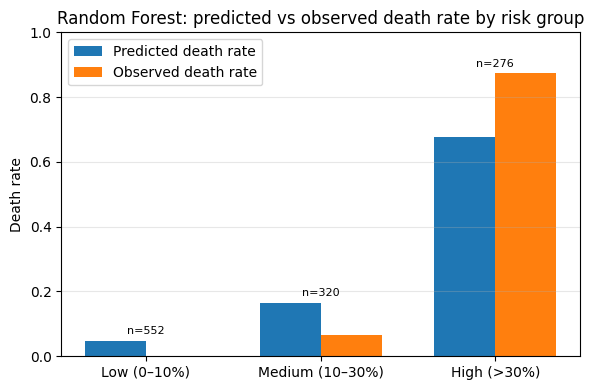

In [42]:
x = calib3["risk_group"].astype(str)
pred = calib3["pred_mean"]
obs  = calib3["obs_rate"]

plt.figure(figsize=(6,4))

w = 0.35
idx = np.arange(len(x))

plt.bar(idx - w/2, pred, width=w, label="Predicted death rate")
plt.bar(idx + w/2, obs,  width=w, label="Observed death rate")

for i, n in enumerate(calib3["n"]):
    plt.text(idx[i], max(pred[i], obs[i]) + 0.02, f"n={n}", ha="center", fontsize=8)

plt.xticks(idx, x, rotation=0)
plt.ylim(0, 1)
plt.ylabel("Death rate")
plt.title("Random Forest: predicted vs observed death rate by risk group")
plt.legend(loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("predicted_vs_observed.png", dpi=300, bbox_inches="tight")
plt.show()


6. Do deaths generally get higher predicted risk than survivors?

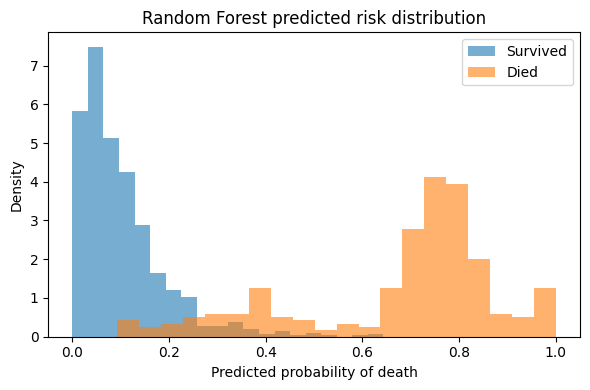

In [43]:
plt.figure(figsize=(6,4))

# survivors
plt.hist(
    y_proba_rf[y_test == 0],
    bins=20,
    alpha=0.6,
    label="Survived",
    density=True
)

# deaths
plt.hist(
    y_proba_rf[y_test == 1],
    bins=20,
    alpha=0.6,
    label="Died",
    density=True
)

plt.xlabel("Predicted probability of death")
plt.ylabel("Density")
plt.title("Random Forest predicted risk distribution")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_risk_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


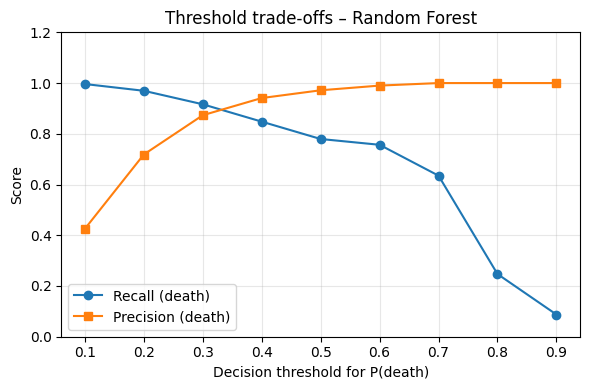

In [44]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.1, 0.9, 9)
precisions = []
recalls = []

for thr in thresholds:
    y_hat_thr = (y_proba_rf >= thr).astype(int)
    precisions.append(precision_score(y_test, y_hat_thr, pos_label=1))
    recalls.append(recall_score(y_test, y_hat_thr, pos_label=1))

plt.figure(figsize=(6,4))
plt.plot(thresholds, recalls,   marker="o", label="Recall (death)")
plt.plot(thresholds, precisions,marker="s", label="Precision (death)")
plt.xlabel("Decision threshold for P(death)")
plt.ylabel("Score")
plt.ylim(0, 1.2)
plt.title("Threshold trade-offs – Random Forest")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("threshold_tradeoffs.png", dpi=300, bbox_inches="tight")
plt.show()
